# Airline Passenger Forecasting using LSTM

## Objective
The goal of this project is to build a Long Short-Term Memory (LSTM) model to predict future airline passengers based on historical monthly data.

### Goals:
- Learn patterns from historical data
- Capture seasonality and trends
- Predict future passenger counts
- Evaluate model accuracy

# Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

C:\Users\Cpu\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Dataset Description

The dataset contains monthly airline passenger data from 1949 to 1960.

Columns:
- Month
- Passengers

In [3]:
df = pd.read_csv('C:/Users/Cpu/Downloads/airline-passengers.csv')

print(df.head())
print("Shape:", df.shape)

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Shape: (144, 2)


## Basic Data Analysis

We check:
- Data types
- Missing values
- Structure of dataset

In [4]:
print(df.dtypes)

Month         object
Passengers     int64
dtype: object


In [5]:
print(df.isnull().sum())

Month         0
Passengers    0
dtype: int64


In [6]:
# Display first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [7]:
# Display last 5 rows
print("\nLast 5 rows:")
print(df.tail())


Last 5 rows:
       Month  Passengers
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432


In [8]:
# Check dataset shape
print("\nShape of dataset:", df.shape)



Shape of dataset: (144, 2)


In [9]:
# Check column names
print("\nColumns:", df.columns)


Columns: Index(['Month', 'Passengers'], dtype='object')


In [10]:
# Check data types
print("\nData Types:")
print(df.dtypes)


Data Types:
Month         object
Passengers     int64
dtype: object


In [11]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Month         0
Passengers    0
dtype: int64


## Data Visualization

Visualizing helps us understand:
- Trend (increasing passengers)
- Seasonality (repeating yearly patterns)

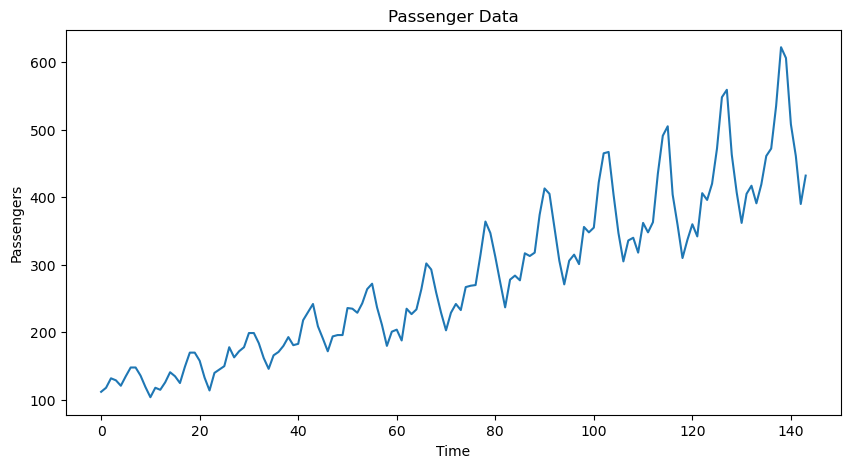

In [12]:
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'])
plt.title("Passenger Data")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()

## Date Conversion

Convert Month column to datetime format.

In [13]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

In [14]:
## Trend Analysis using Moving Average

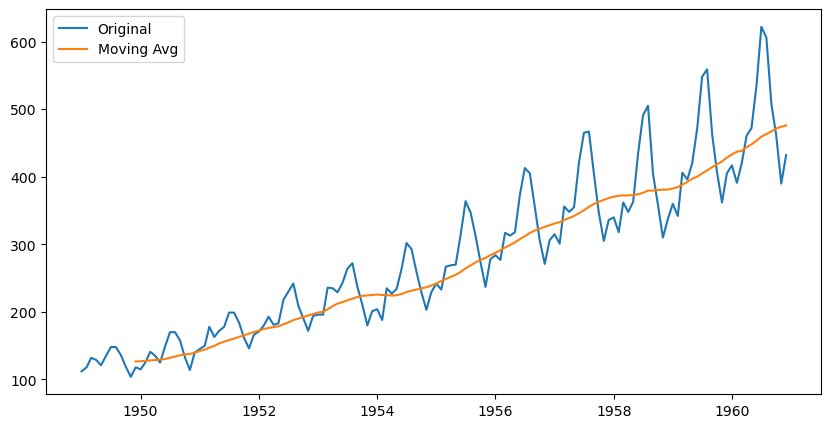

In [15]:
df['Moving_Avg'] = df['Passengers'].rolling(window=12).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Original')
plt.plot(df['Moving_Avg'], label='Moving Avg')
plt.legend()
plt.show()

## Data Preprocessing

Steps:
- Extract values
- Normalize data

In [18]:
data = df['Passengers'].values
data = data.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

## Train-Test Split

In [19]:
train_size = int(len(data_scaled)*0.7)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

## Sequence Creation

We create sequences for LSTM input.

In [20]:
def create_dataset(dataset, time_step=5):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step),0])
        Y.append(dataset[i+time_step,0])
    return np.array(X), np.array(Y)

time_step = 5

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

## Reshaping Data for LSTM

In [21]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1],1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1],1)

## Model Building

In [22]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

C:\Users\Cpu\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Model Training

In [23]:
model.fit(X_train, y_train, epochs=100, batch_size=1)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0169 
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082   
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078     
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063 
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0058 
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0069     
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061 
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063     
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054       
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053     
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047     
Epoch 13/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0052 
Epoch 14/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 
Epoch 15/100
94/94 ━━━━━━━━━━

## Prediction

In [25]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


## Model Evaluation

In [26]:
rmse = math.sqrt(mean_squared_error(y_test_actual, test_predict))
print("RMSE:", rmse)

RMSE: 44.675237385718866


## Visualization of Results

ValueError: could not broadcast input array from shape (94,) into shape (94,1)

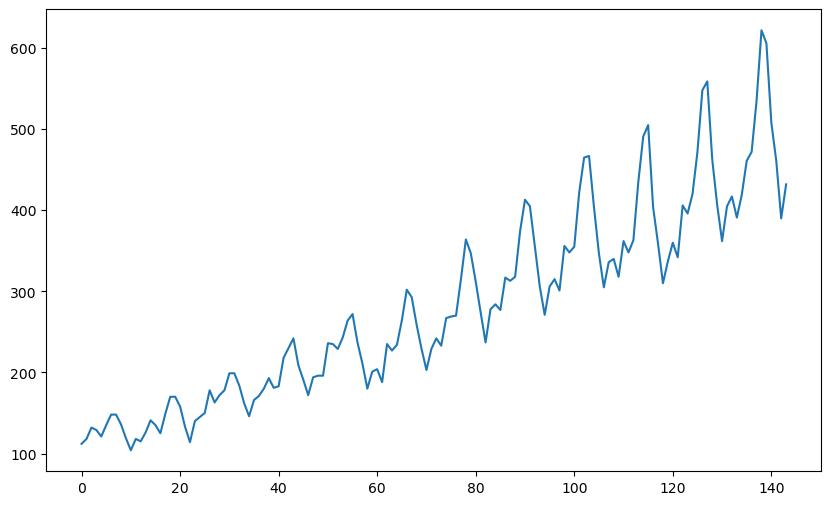

In [31]:
plt.figure(figsize=(10,6))
plt.plot(data, label='Original')

# Train plot
train_plot = np.empty_like(data, dtype=float)
train_plot[:] = np.nan
train_plot[time_step:len(train_predict)+time_step] = train_predict.flatten()

# Test plot
test_plot = np.empty_like(data, dtype=float)
test_plot[:] = np.nan
test_plot[len(train_predict)+(time_step*2)+1:len(data)-1] = test_predict.flatten()

plt.plot(train_plot, label='Train')
plt.plot(test_plot, label='Test')

plt.legend()
plt.show()

## Future Prediction

Predict next 10 months passenger values.

In [32]:
last_data = data_scaled[-time_step:]
temp_input = list(last_data.reshape(1,-1)[0])
future_output = []

for i in range(10):
    x_input = np.array(temp_input[-time_step:])
    x_input = x_input.reshape(1, time_step, 1)

    yhat = model.predict(x_input, verbose=0)
    temp_input.append(yhat[0][0])
    future_output.append(yhat[0][0])

future_output = scaler.inverse_transform(np.array(future_output).reshape(-1,1))

print("Future Predictions:", future_output)

Future Predictions: [[465.43945]
 [496.673  ]
 [551.06085]
 [552.86707]
 [490.4262 ]
 [440.32367]
 [423.60846]
 [451.86136]
 [497.3152 ]
 [550.7259 ]]


## Conclusion

The LSTM model successfully learned patterns and predicted future airline passengers.

